# Colab'a hoş geldiniz.

# Machine Learning Methods

In the previous stages, EDA and hypothesis testing showed weak relationships between inflation, fast food density, and obesity rates.

In this section, machine learning methods are applied to evaluate whether inflation and fast food availability can be used to predict obesity rates across countries.

The target variable is obesity rate, and the predictors are inflation rate and fast food density per million people.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving merged_dataset.csv to merged_dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

merged = pd.read_csv("merged_dataset.csv")
merged.head()

,country,year,inflation_rate,obesity_rate,population,fast_food_count,fast_food_per_million
0,United Arab Emirates,2022,5.291226,32.07922,10074977.0,103,10.223348
1,Argentina,2022,72.430758,35.35520,45407904.0,217,4.778904
2,Australia,2022,6.594097,30.24391,26018721.0,1014,38.971939
3,Austria,2022,8.546870,15.36754,9041851.0,203,22.451155
4,Azerbaijan,2022,13.852259,26.54888,10141756.0,23,2.267852


In [3]:
X = merged[["inflation_rate", "fast_food_per_million"]]
y = merged["obesity_rate"]

print(X.head())
print(y.head())

   inflation_rate  fast_food_per_million
0        5.291226              10.223348
1       72.430758               4.778904
2        6.594097              38.971939
3        8.546870              22.451155
4       13.852259               2.267852
0    32.07922
1    35.35520
2    30.24391
3    15.36754
4    26.54888
Name: obesity_rate, dtype: float64


The features used in the model are inflation rate and fast food density per million people. The target variable is obesity rate. Since the target variable is numerical, this is a regression problem.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (63, 2)
Testing set size: (16, 2)


In [5]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression Results")
print("RMSE:", linear_rmse)
print("MAE:", linear_mae)
print("R2 Score:", linear_r2)
print("Intercept:", linear_model.intercept_)
print("Coefficients:", linear_model.coef_)

Linear Regression Results
RMSE: 7.384006833874167
MAE: 5.978650596908162
R2 Score: -0.00954875733624383
Intercept: 24.689909248951423
Coefficients: [0.03057618 0.02119196]


Linear regression is used as a baseline model because it is simple and interpretable. It estimates whether inflation and fast food density have a linear relationship with obesity rates.

In [6]:
tree_model = DecisionTreeRegressor(random_state=42, max_depth=3)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_mse = mean_squared_error(y_test, tree_pred)
tree_rmse = np.sqrt(tree_mse)
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree Results")
print("RMSE:", tree_rmse)
print("MAE:", tree_mae)
print("R2 Score:", tree_r2)

Decision Tree Results
RMSE: 7.6653750472540825
MAE: 6.0919153851744205
R2 Score: -0.08795250354506856


A decision tree regressor is applied to capture possible non-linear relationships between the predictors and obesity rates. The tree depth is limited to reduce overfitting.

In [7]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=3
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R2 Score:", rf_r2)

Random Forest Results
RMSE: 6.707891227064674
MAE: 5.46746082404311
R2 Score: 0.1668654559918673


Random Forest is used as an ensemble method. It combines multiple decision trees and can capture more complex patterns than a single linear model.

In [8]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "RMSE": [linear_rmse, tree_rmse, rf_rmse],
    "MAE": [linear_mae, tree_mae, rf_mae],
    "R2 Score": [linear_r2, tree_r2, rf_r2]
})

results

,Model,RMSE,MAE,R2 Score
0,Linear Regression,7.384007,5.978651,-0.009549
1,Decision Tree,7.665375,6.091915,-0.087953
2,Random Forest,6.707891,5.467461,0.166865


The models are compared using RMSE, MAE, and R-squared. Lower RMSE and MAE indicate better predictive performance, while a higher R-squared value indicates that the model explains more variation in obesity rates.

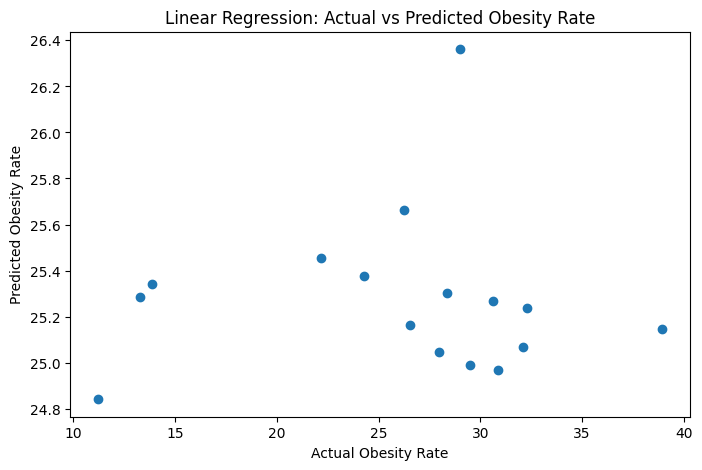

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, linear_pred)
plt.xlabel("Actual Obesity Rate")
plt.ylabel("Predicted Obesity Rate")
plt.title("Linear Regression: Actual vs Predicted Obesity Rate")
plt.show()

In [10]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
1,fast_food_per_million,0.644896
0,inflation_rate,0.355104


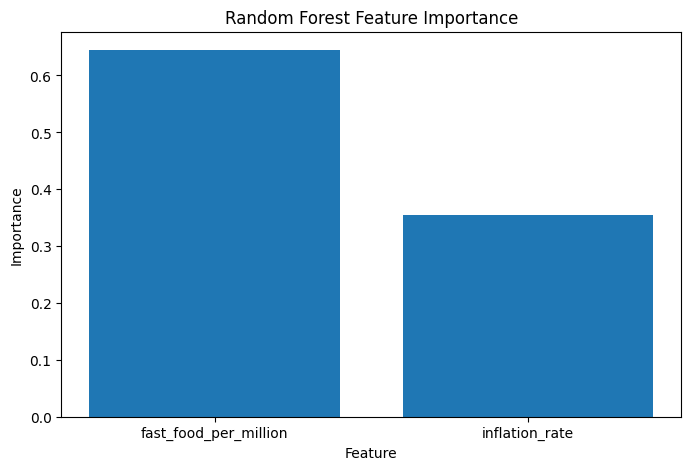

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.show()

Feature importance from the random forest model shows which variables contributed more to prediction. However, feature importance does not imply causation.

## Machine Learning Results

The machine learning models show very limited predictive power.

- Linear Regression produced an R-squared value close to zero, indicating no explanatory power.
- Decision Tree performed even worse, suggesting overfitting or lack of meaningful patterns.
- Random Forest achieved the highest R-squared value (~0.17), but this is still considered weak.

Overall, none of the models were able to effectively predict obesity rates using inflation and fast food density.

These results are consistent with the findings from the EDA and hypothesis testing stages, where weak and statistically insignificant relationships were observed.

This suggests that obesity is influenced by more complex factors that are not captured in this dataset.

In [12]:
results

,Model,RMSE,MAE,R2 Score
0,Linear Regression,7.384007,5.978651,-0.009549
1,Decision Tree,7.665375,6.091915,-0.087953
2,Random Forest,6.707891,5.467461,0.166865
